# Introduction  

**What is Autogloun**  
AutoGluon is an open-source AutoML (Automated Machine Learning) library developed by Amazon Web Services (AWS). It enables developers and data scientists to quickly build accurate machine learning models

[**Website**](https://auto.gluon.ai/)  
[**GitHub**](https://github.com/autogluon/autogluon)

**Dataset info**  
Half-hourly UK electricity demand data (2009-2024) from [National Grid ESO] (https://www.neso.energy/), including national demand, renewable generation estimates, and interconnector flows.






# Setup: Libraries and Data

Install the AutoGluon library, import the required libraries, and load the dataset.



In [ ]:
# Install the autogluon library
#!pip install -q autogluon

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from autogluon.timeseries import TimeSeriesDataFrame, TimeSeriesPredictor
from autogluon.timeseries.splitter import ExpandingWindowSplitter

In [10]:
# Load the data
df = pd.read_csv("UK_electricity_wind_2021_2024.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68872 entries, 0 to 68871
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   settlement_date           68872 non-null  object 
 1   england_wales_demand      68872 non-null  float64
 2   is_holiday                68872 non-null  int64  
 3   item_id                   68872 non-null  object 
 4   embedded_wind_generation  68872 non-null  int64  
 5   embedded_wind_capacity    68872 non-null  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 3.2+ MB


# Data Processing and Visualization

We rename the target column, preview the data, plot the target, and assess its basic structure.

In [11]:
# set time stamp to_datetime
df["settlement_date"] = pd.to_datetime(df["settlement_date"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68872 entries, 0 to 68871
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   settlement_date           68872 non-null  datetime64[ns]
 1   england_wales_demand      68872 non-null  float64       
 2   is_holiday                68872 non-null  int64         
 3   item_id                   68872 non-null  object        
 4   embedded_wind_generation  68872 non-null  int64         
 5   embedded_wind_capacity    68872 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 3.2+ MB


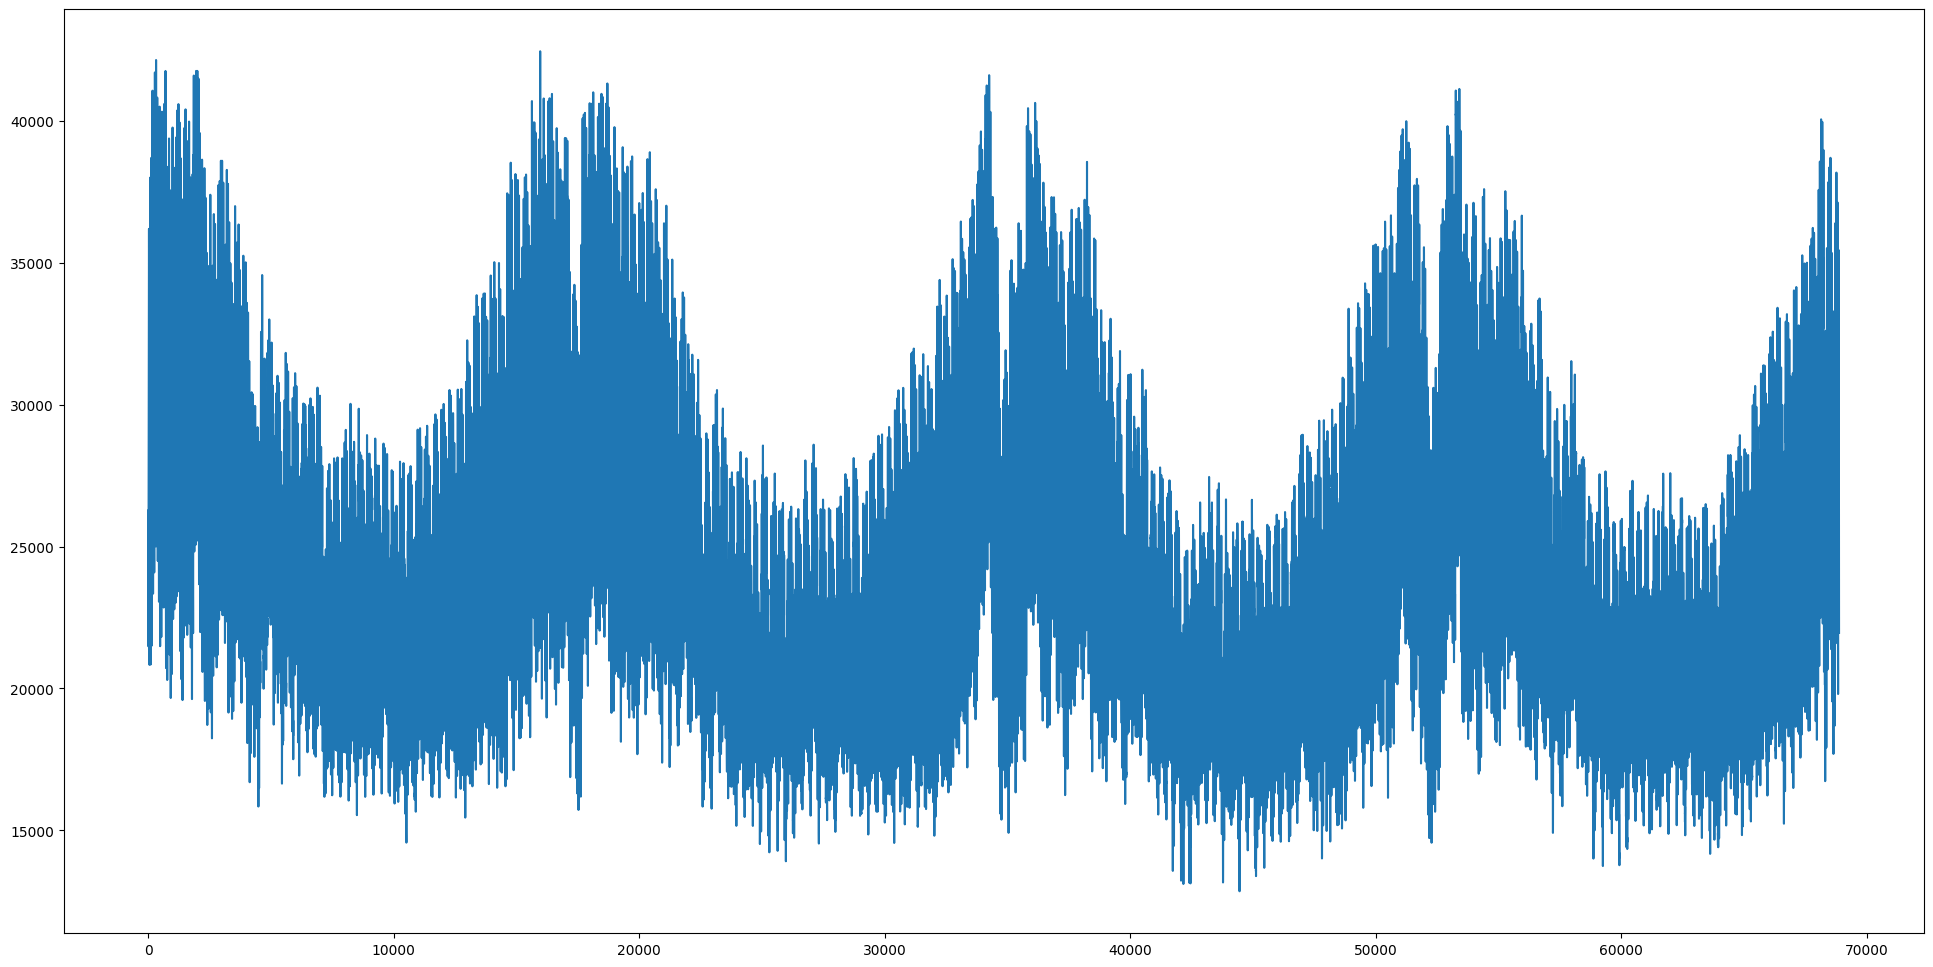

In [5]:
# Visualize the target variable over time
df.england_wales_demand.plot(figsize=(24, 12))
plt.show()

# Autogluon Model - Simple

We specify a prediction length and build a simple AutoGluon time-series model. 
We train it, list the models used, check the leaderboard, and generate predictions.

For a list of timeseries forecasting models trained by AutGluon see [here](https://auto.gluon.ai/dev/tutorials/timeseries/forecasting-model-zoo.html)  
The portfolio is comprehensive of:  
- baseline models  
- statistical models  
- deep learning models  
- tabular models  
- pre-trained models 
  

## AutoGluon TimeSeriesDataFrame parameters

  

**id_column**:  
It just tells AutoGluon that all rows belong to one single time series.  
If the dataset has two locations (England and Wales) the time series has two groups. In this case we have only one.  

**static_features_df**   
it defines the attributes that are constant in the dataframe - attributes that do change between time series (eg. between England and Wales).   
For your UK dataset with a single series, static features aren't very useful since there's only one time series.

In [6]:
df

,settlement_date,england_wales_demand,is_holiday,item_id,embedded_wind_generation,embedded_wind_capacity
0,2021-01-01 00:00:00,26130.0,1,UK,1018,6527
1,2021-01-01 00:30:00,26281.0,1,UK,1026,6527
2,2021-01-01 01:00:00,25557.0,1,UK,1039,6527
3,2021-01-01 01:30:00,24792.0,1,UK,1052,6527
4,2021-01-01 02:00:00,23933.0,1,UK,1076,6527
...,...,...,...,...,...,...
68867,2024-12-05 21:30:00,27212.0,0,UK,5377,6622
68868,2024-12-05 22:00:00,25477.0,0,UK,5486,6622
68869,2024-12-05 22:30:00,24428.0,0,UK,5594,6622
68870,2024-12-05 23:00:00,22590.0,0,UK,5575,6622


In [7]:
# Convert raw data into a TimeSeriesDataFrame

from autogluon.timeseries import TimeSeriesDataFrame

timeseries_df = TimeSeriesDataFrame(df, 
                                    id_column = "item_id", 
                                    timestamp_column="settlement_date" )

timeseries_df

england_wales_demand  is_holiday  \
item_id timestamp                                               
UK      2021-01-01 00:00:00               26130.0           1   
        2021-01-01 00:30:00               26281.0           1   
        2021-01-01 01:00:00               25557.0           1   
        2021-01-01 01:30:00               24792.0           1   
        2021-01-01 02:00:00               23933.0           1   
...                                           ...         ...   
        2024-12-05 21:30:00               27212.0           0   
        2024-12-05 22:00:00               25477.0           0   
        2024-12-05 22:30:00               24428.0           0   
        2024-12-05 23:00:00               22590.0           0   
        2024-12-05 23:30:00               21958.0           0   

                             embedded_wind_generation  embedded_wind_capacity  
item_id timestamp                                                              
UK      2021-01-01 00:00:00                      1018                    6527  
        2021-01-01 00:30:00                      1026                    6527  
        2021-01-01 01:00:00                      1039                    6527  
        2021-01-01 01:30:00                      1052                    6527  
        2021-01-01 02:00:00                      1076                    6527  
...                                               ...                     ...  
        2024-12-05 21:30:00                      5377                    6622  
        2024-12-05 22:00:00                      5486                    6622  
        2024-12-05 22:30:00                      5594                    6622  
        2024-12-05 23:00:00                      5575                    6622  
        2024-12-05 23:30:00                      5556                    6622  

[68872 rows x 4 columns]

In [8]:
# split the dataset in train and test

from sklearn.model_selection import train_test_split
train, test = train_test_split(timeseries_df, test_size=0.2)

In [9]:
# check train
train.info()

<class 'autogluon.timeseries.dataset.ts_dataframe.TimeSeriesDataFrame'>
MultiIndex: 55097 entries, ('UK', Timestamp('2024-09-22 03:00:00')) to ('UK', Timestamp('2023-07-22 01:00:00'))
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   england_wales_demand      55097 non-null  float64
 1   is_holiday                55097 non-null  int64  
 2   embedded_wind_generation  55097 non-null  int64  
 3   embedded_wind_capacity    55097 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 4.5+ MB


## Training

Create the model defining the parameters and train it to forecast the values

In [12]:
# predict one week ahead = (2*24)*7=336
prediction_length = 336 #one week length

In [14]:
timeseries_df.columns

Index(['england_wales_demand', 'is_holiday', 'embedded_wind_generation',
       'embedded_wind_capacity'],
      dtype='object')

In [16]:
# Initialize the TimeSeriesPredictor with essential parameters
predictor = TimeSeriesPredictor(
    target="england_wales_demand", 
    prediction_length=prediction_length, 
    freq="30min",
    eval_metric="RMSE"
)

### Model Parameters

**presets**  
Controls the number and complexity of models AutoGluon will train:

- `high_quality`: 12+ models (most thorough, slowest)
- `medium_quality`: 5–8 models (balanced)
- `low_quality`: fewer models (fastest, least accurate)

**num_val_windows**  
Number of validation windows used to evaluate model performance. Each window has the same length as `prediction_length` (in our case, 1 week). AutoGluon computes the evaluation metric (e.g., MAPE) on each window and averages the results.

Practical guidelines:
- 3 — quick iteration, good for initial experiments
- 5–10 — more robust evaluation, recommended for final models
- >10 — diminishing returns, significantly slower

**val_step_size**  
The offset (in time steps) between consecutive validation windows. With `val_step_size = 96` (2 days of 30-min intervals), each window starts 2 days before the previous one:

Note: Only the validation windows are used to compute metrics. All data *before* each window is used for training.

**random_seed**  
Fixes the random number generator to ensure reproducible results across runs.


In [18]:
# Train the model with specified presets, validation steps, and time limits
predictor.fit(
    train,
    presets="medium_quality", 
    time_limit=1200, 
    num_val_windows=3, 
    val_step_size=96,
    random_seed=1502
)

Beginning AutoGluon training... Time limit = 1200s
AutoGluon will save models to 'c:\Users\fc\Documents\GitHub repository\time_series_forecasting\AutogluonModels\ag-20260203_134639'
=================== System Info ===================
AutoGluon Version:  1.3.0
Python Version:     3.11.11
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          16
GPU Count:          0
Memory Avail:       5.00 GB / 14.83 GB (33.7%)
Disk Space Avail:   274.49 GB / 475.66 GB (57.7%)
Setting presets to: medium_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': '30min',
 'hyperparameters': 'light',
 'known_covariates_names': [],
 'num_val_windows': 3,
 'prediction_length': 336,
 'quantile_levels': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
 'random_seed': 1502,
 'refit_every_n_windows': 1,
 'refit_full': False,
 'skip_model_selection': False,
 'target': 'england_wales_demand',
 'time_limit': 1200,
 'val_step_size': 96,

In [20]:
# List the model_names
predictor.model_names()

['Naive',
 'SeasonalNaive',
 'RecursiveTabular',
 'DirectTabular',
 'ETS',
 'Theta',
 'Chronos[bolt_small]',
 'TemporalFusionTransformer',
 'WeightedEnsemble']

## Monitoring

**leaderboard**:  
Normally, error metrics like RMSE, MASE, MAPE are "lower is better" — a smaller error means a better model. But AutoGluon standardizes all metrics to **"higher is better"**. This means that metrics such as MASE or MAPE will be multiplied by -1, so their values will be negative.  


Raw RMSE	AutoGluon score
3.27	-3.27
4.15	-4.15
So -3.27 is better than -4.15 because it's higher (closer to zero).

In [21]:
# Show performance (.leaderboard) of trained models
predictor.leaderboard()

,model,score_val,pred_time_val,fit_time_marginal,fit_order
0,WeightedEnsemble,-1424.640304,20.748534,1.146244,9
1,Chronos[bolt_small],-1797.215522,2.036766,13.705395,7
2,DirectTabular,-1883.768016,0.948614,8.941903,4
3,RecursiveTabular,-2664.528382,10.164259,61.104954,3
4,TemporalFusionTransformer,-3439.786364,0.102256,503.775877,8
5,Theta,-3681.237761,2.591425,4.342195,6
6,SeasonalNaive,-3991.253584,3.571528,7.403597,2
7,ETS,-8012.735207,3.839914,14.953310,5
8,Naive,-8012.920431,3.758981,9.080271,1


## Prediction

In [ ]:
# Generate predictions using the trained model
# it performs the model with the best prediction score (see leaderboard)

predictions = predictor.predict(
    timeseries_df, 
    random_seed=1502
)



data with frequency 'IRREG' has been resampled to frequency '30min'.
Model not specified in predict, will default to the model with the best validation score: WeightedEnsemble


In [23]:
predictions

mean           0.1           0.2  \
item_id timestamp                                                       
UK      2024-12-06 00:00:00  22858.727427  21035.650813  21671.623829   
        2024-12-06 00:30:00  22988.294810  20466.092522  21347.978430   
        2024-12-06 01:00:00  22691.096568  19634.328504  20701.399380   
        2024-12-06 01:30:00  22268.485240  18779.901724  19986.530092   
        2024-12-06 02:00:00  21830.772349  17939.725387  19283.467867   
...                                   ...           ...           ...   
        2024-12-12 21:30:00  27090.397837  -3265.029707   7178.332680   
        2024-12-12 22:00:00  25643.141001  -4736.966098   5710.810228   
        2024-12-12 22:30:00  24474.374156  -5950.302304   4500.759104   
        2024-12-12 23:00:00  23227.151988  -7214.583755   3234.694530   
        2024-12-12 23:30:00  22717.443980  -7738.697186   2720.224017   

                                      0.3           0.4           0.5  \
item_id timestamp                                                       
UK      2024-12-06 00:00:00  22122.432362  22504.017456  22858.727973   
        2024-12-06 00:30:00  21971.185734  22501.326657  22988.295557   
        2024-12-06 01:00:00  21453.278489  22095.367380  22691.096166   
        2024-12-06 01:30:00  20855.028496  21586.127183  22268.485125   
        2024-12-06 02:00:00  20251.518674  21068.214632  21830.773038   
...                                   ...           ...           ...   
        2024-12-12 21:30:00  14688.861075  21097.555585  27090.398469   
        2024-12-12 22:00:00  13228.704476  19640.052361  25643.141461   
        2024-12-12 22:30:00  12024.958883  18459.735774  24474.374515   
        2024-12-12 23:00:00  10766.407174  17202.631928  23227.152605   
        2024-12-12 23:30:00  10255.402050  16696.600915  22717.444770   

                                      0.6           0.7           0.8  \
item_id timestamp                                                       
UK      2024-12-06 00:00:00  23209.314466  23587.542138  24036.512781   
        2024-12-06 00:30:00  23477.158499  23999.192001  24621.270398   
        2024-12-06 01:00:00  23285.304443  23919.388451  24665.757307   
        2024-12-06 01:30:00  22950.210743  23684.248882  24538.415744   
        2024-12-06 02:00:00  22588.925195  23402.798399  24358.095788   
...                                   ...           ...           ...   
        2024-12-12 21:30:00  33091.529440  39514.238110  47036.338282   
        2024-12-12 22:00:00  31643.887299  38073.433915  45597.946327   
        2024-12-12 22:30:00  30491.178783  36932.543565  44474.545102   
        2024-12-12 23:00:00  29257.251895  35705.318447  43253.729333   
        2024-12-12 23:30:00  28752.172414  35211.761415  42774.489253   

                                      0.9  
item_id timestamp                          
UK      2024-12-06 00:00:00  24663.035601  
        2024-12-06 00:30:00  25486.390193  
        2024-12-06 01:00:00  25704.675839  
        2024-12-06 01:30:00  25728.241865  
        2024-12-06 02:00:00  25683.294810  
...                                   ...  
        2024-12-12 21:30:00  57474.663072  
        2024-12-12 22:00:00  56049.581051  
        2024-12-12 22:30:00  54946.616763  
        2024-12-12 23:00:00  53723.049610  
        2024-12-12 23:30:00  53253.711237  

[336 rows x 10 columns]

data with frequency 'IRREG' has been resampled to frequency '30min'.


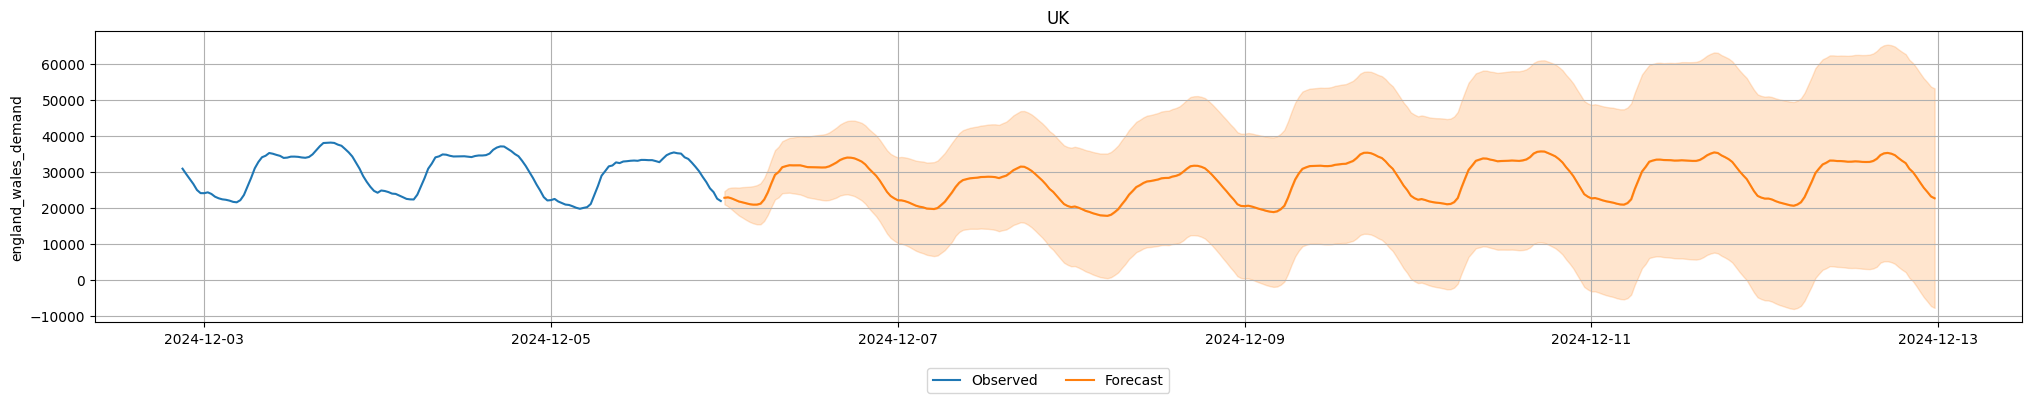

In [25]:
# Plot the actual time series (timeseries_df) along with the model predictions (predictions)

predictor.plot(timeseries_df, predictions, max_history_length=150);
plt.show()

We have a simple model trained on the data. The seasonality is more or less stable, but the CI becomes quite wide. 